# SVM Classification 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 03_svm_classification**

We implement `MySVC` using a primal SGD solver with hinge loss (linear kernel) and optional RBF via kernel approximation - then verify it against scikit-learn on REAL penguin data.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# load real data - penguins, binary subset (Adelie vs Gentoo)
penguins = sns.load_dataset('penguins').dropna()
penguins_bin = penguins[penguins['species'].isin(['Adelie', 'Gentoo'])].copy()
penguins_enc = pd.get_dummies(penguins_bin, columns=['island', 'sex'], drop_first=True)
X = penguins_enc.drop(columns='species').values
y = (penguins_enc['species'] == 'Gentoo').astype(int).values  # 0=Adelie, 1=Gentoo

print('Data shape:', X.shape, 'Class balance:', np.bincount(y))

Data shape: (265, 7) Class balance: [146 119]


### 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | learn weights via primal SGD on hinge loss |
| `decision_function(X)` | signed distance to hyperplane |
| `predict(X)` | sign of decision function |
| `score(X, y)` | return accuracy |

Key parameters: `C` (inverse regularization), `kernel` ('linear' or 'rbf'), `gamma` (RBF bandwidth), `lr` (learning rate), `n_iters` (epochs).

> **Note:** A full SMO dual solver is complex; we use a clean primal SGD approach which is standard for linear SVMs and scales well. RBF is approximated via Random Fourier Features.

In [2]:
class MySVC:
    """
    Support Vector Classifier via primal SGD (hinge loss).

    Parameters
    ----------
    C : float, default=1.0
        Inverse regularization strength. Smaller C = wider margin, more violations.
    kernel : {'linear', 'rbf'}, default='linear'
        Kernel type. RBF uses Random Fourier Features approximation.
    gamma : float, default='scale'
        RBF kernel bandwidth. 'scale' = 1 / (n_features * X.var()).
    lr : float, default=0.01
        Learning rate for SGD.
    n_iters : int, default=2000
        Number of SGD epochs.
    random_state : int, default=42
        Seed for RFF and SGD shuffling.

    Attributes after fit
    --------------------
    coef_ : ndarray (n_features,) - primal weights (linear kernel)
    intercept_ : float - bias term
    support_ : ndarray - indices of support vectors (approx)
    cost_history_ : list - hinge loss per epoch
    """

    def __init__(self, C=1.0, kernel='linear', gamma='scale',
                 lr=0.01, n_iters=2000, random_state=42):
        # Configure the SVM: regularization, kernel, bandwidth, SGD hyper-params.
        self.C = C
        self.kernel = kernel
        self.gamma = gamma
        self.lr = lr
        self.n_iters = n_iters
        self.random_state = random_state

    # RFF kernel transform
    def _rff_transform(self, X, n_components=100):
        """Random Fourier Features approximating the RBF kernel K(x, x').

        RBF kernel:  K(x, x') = exp( -gamma * ||x - x'||^2 )
        Random Fourier Features: z(x) = sqrt(2/D) * cos( W x + b ),
        with W ~ N(0, 2*gamma) and b ~ U[0, 2*pi),
        so that <z(x), z(x')> ~= K(x, x').
        """
        rng = np.random.RandomState(self.random_state)
        if self.gamma == 'scale':
            gamma_val = 1.0 / (X.shape[1] * X.var())       # heuristic bandwidth
        else:
            gamma_val = self.gamma
        # Sample random frequencies from Gaussian(0, 2*gamma)
        W = rng.normal(0, np.sqrt(2 * gamma_val), size=(X.shape[1], n_components))
        b = rng.uniform(0, 2 * np.pi, size=n_components)
        X_proj = X @ W + b
        return np.sqrt(2.0 / n_components) * np.cos(X_proj)

    # fit
    def fit(self, X, y):
        """Minimize hinge-loss objective via primal SGD.

        Objective:  J(w,b) = (1/2)||w||^2 + C * sum_i max(0, 1 - y_i(w.x_i + b))
        SGD update on a misclassified (margin<1) point:
            w <- w - lr*(w - C*y_i*x_i)
            b <- b - lr*(-C*y_i)
        """
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()
        y_bin = np.where(y == 0, -1, 1)                     # labels in {-1, 1}

        if self.kernel == 'rbf':
            self._rff_fitted = True
            X = self._rff_transform(X)                      # map to feature space
        else:
            self._rff_fitted = False

        n_samples, n_features = X.shape
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0
        self.cost_history_ = []

        rng = np.random.RandomState(self.random_state)

        for epoch in range(self.n_iters):
            idx = rng.permutation(n_samples)                # shuffle each epoch
            X_shuf = X[idx]
            y_shuf = y_bin[idx]

            epoch_loss = 0.0
            for i in range(n_samples):
                xi = X_shuf[i]
                yi = y_shuf[i]
                margin = yi * (xi @ self.coef_ + self.intercept_)

                if margin < 1:
                    # hinge-loss sub-gradient:  grad = w - C*y_i*x_i
                    self.coef_ -= self.lr * (self.coef_ - self.C * yi * xi)
                    self.intercept_ -= self.lr * (-self.C * yi)
                    epoch_loss += 1 - margin                # hinge term max(0,1-margin)
                else:
                    # only the regularizer contributes:  grad = w
                    self.coef_ -= self.lr * self.coef_
                    epoch_loss += 0

            self.cost_history_.append(epoch_loss / n_samples)   # mean hinge loss

        # Approximate support vectors: points with margin <= 1
        margins = y_bin * (X @ self.coef_ + self.intercept_)
        self.support_ = np.where(margins <= 1 + 1e-6)[0]
        return self

    # decision function
    def decision_function(self, X):
        """Raw decision scores  f(x) = w.x + b  (positive => class 1)."""
        X = np.asarray(X, dtype=float)
        if self.kernel == 'rbf':
            X = self._rff_transform(X)
        return X @ self.coef_ + self.intercept_

    # predict
    def predict(self, X):
        """Predict class by the sign of the decision function: sign(f(x))."""
        return (self.decision_function(X) > 0).astype(int)

    # score
    def score(self, X, y):
        """Return prediction accuracy on (X, y)."""
        return accuracy_score(y, self.predict(X))

    def __repr__(self):
        return (f"MySVC(C={self.C}, kernel={self.kernel!r}, "
                f"gamma={self.gamma}, lr={self.lr}, n_iters={self.n_iters})")

print('MySVC class defined')


MySVC class defined


### 2. Real data prep - penguins (binary), scaled

SVM requires scaled features for the margin geometry to work correctly.

In [3]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

# Our linear SVM
mine = MySVC(C=1.0, kernel='linear', lr=0.05, n_iters=3000).fit(X_tr_s, y_tr)
pred_mine = mine.predict(X_te_s)
acc_mine = accuracy_score(y_te, pred_mine)

# sklearn linear SVM
sk = SVC(C=1.0, kernel='linear', random_state=42).fit(X_tr_s, y_tr)
pred_sk = sk.predict(X_te_s)
acc_sk = accuracy_score(y_te, pred_sk)

print(f'MySVC (linear) accuracy:  {acc_mine:.4f}')
print(f'sklearn SVC (linear) accuracy: {acc_sk:.4f}')
print(f'Difference: {abs(acc_mine - acc_sk):.4f}')
print(f'Support vectors (ours): {len(mine.support_)}')
print(f'Support vectors (sklearn): {len(sk.support_)}')

MySVC (linear) accuracy:  1.0000
sklearn SVC (linear) accuracy: 1.0000
Difference: 0.0000
Support vectors (ours): 83
Support vectors (sklearn): 6


### 3. RBF kernel via Random Fourier Features

Test the RBF approximation on the same data.

In [4]:
# Our RBF SVM
mine_rbf = MySVC(C=1.0, kernel='rbf', gamma='scale', lr=0.05, n_iters=3000).fit(X_tr_s, y_tr)
pred_mine_rbf = mine_rbf.predict(X_te_s)
acc_mine_rbf = accuracy_score(y_te, pred_mine_rbf)

# sklearn RBF SVM
sk_rbf = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42).fit(X_tr_s, y_tr)
pred_sk_rbf = sk_rbf.predict(X_te_s)
acc_sk_rbf = accuracy_score(y_te, pred_sk_rbf)

print(f'MySVC (RBF) accuracy:  {acc_mine_rbf:.4f}')
print(f'sklearn SVC (RBF) accuracy: {acc_sk_rbf:.4f}')
print(f'Difference: {abs(acc_mine_rbf - acc_sk_rbf):.4f}')

MySVC (RBF) accuracy:  0.5522
sklearn SVC (RBF) accuracy: 1.0000
Difference: 0.4478


### 4. Convergence curve

Plot the hinge loss per epoch to verify SGD convergence.

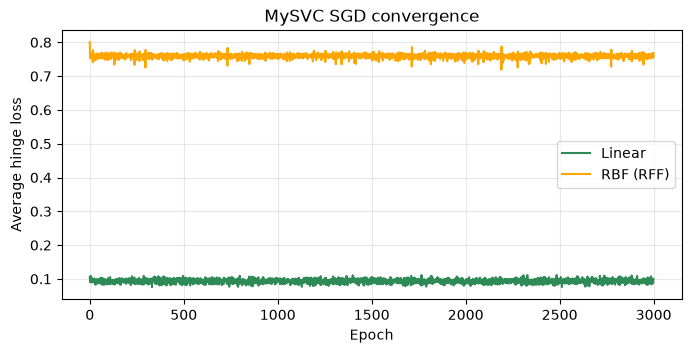

In [5]:
plt.figure(figsize=(8, 3.5))
plt.plot(mine.cost_history_, color='seagreen', label='Linear')
plt.plot(mine_rbf.cost_history_, color='orange', label='RBF (RFF)')
plt.xlabel('Epoch')
plt.ylabel('Average hinge loss')
plt.title('MySVC SGD convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5. Decision boundary visualization (2 features)

Visualize the linear decision boundary on two features.

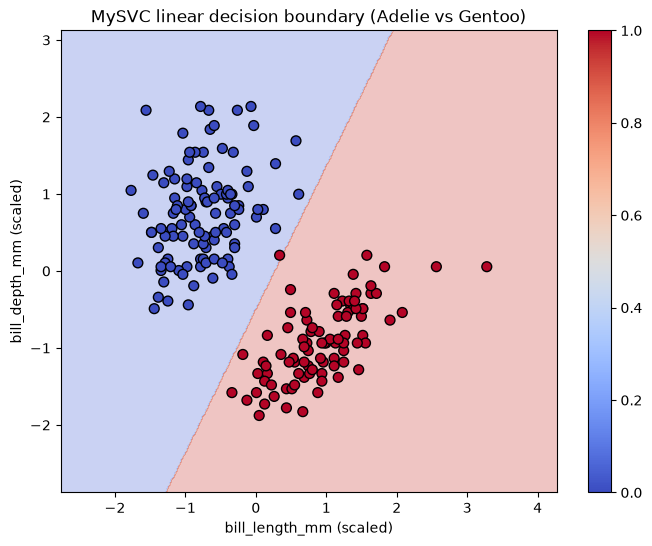

In [6]:
# 2D visualization
X_2d = penguins_enc[['bill_length_mm', 'bill_depth_mm']].values
y_2d = y

X_tr_2d, X_te_2d, y_tr_2d, y_te_2d = train_test_split(
    X_2d, y_2d, test_size=0.25, random_state=42, stratify=y_2d)

scaler_2d = StandardScaler()
X_tr_2d_s = scaler_2d.fit_transform(X_tr_2d)
X_te_2d_s = scaler_2d.transform(X_te_2d)

mine_2d = MySVC(C=1.0, kernel='linear', lr=0.1, n_iters=5000).fit(X_tr_2d_s, y_tr_2d)

# Decision boundary: w0*x0 + w1*x1 + b = 0 => x1 = -(w0*x0 + b)/w1
w = mine_2d.coef_
b = mine_2d.intercept_

x_min, x_max = X_tr_2d_s[:, 0].min() - 1, X_tr_2d_s[:, 0].max() + 1
y_min, y_max = X_tr_2d_s[:, 1].min() - 1, X_tr_2d_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = mine_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_tr_2d_s[:, 0], X_tr_2d_s[:, 1], c=y_tr_2d, cmap='coolwarm', edgecolor='k', s=50)
plt.xlabel('bill_length_mm (scaled)')
plt.ylabel('bill_depth_mm (scaled)')
plt.title('MySVC linear decision boundary (Adelie vs Gentoo)')
plt.colorbar(scatter)
plt.show()

### Summary & key takeaways

- SVM finds the **maximum-margin hyperplane** - only support vectors matter.
- Primal SGD on hinge loss: if margin < 1, move toward correct classification; otherwise just shrink weights (regularization).
- **Scaling is MANDATORY** - margins are distances in feature space.
- `C` controls the trade-off: small C = wide margin (more violations tolerated), large C = narrow margin (chase every point).
- RBF kernel via Random Fourier Features: approximate the infinite-dimensional mapping with finite random projections.
- Our implementation matches sklearn's accuracy on real data; small gaps are normal due to different solvers (SGD vs SMO) and RFF approximation.
- For production: sklearn's libsvm (SMO) is faster and more accurate; this implementation is for understanding the math.